In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

In [2]:
df = pd.read_csv("clean_data.csv")
df.head()

,incident_id,incident_category,severity,incident_description,resolution_status,location,clean_text
0,1,Customs Issue,Low,Customs clearance process delayed. Reported at...,Open,Delhi,customs clearance process delay report chennai...
1,2,Customs Issue,Medium,Customs clearance process delayed. Reported at...,Open,Mumbai,customs clearance process delay report mumbai ...
2,3,Inventory Shortage,Low,Demand exceeded available stock levels. Report...,Resolved,Kolkata,demand exceed available stock level report che...
3,4,Inventory Shortage,High,Inventory forecast underestimated demand. Repo...,Open,Kolkata,inventory forecast underestimate demand report...
4,5,Damaged Goods,Critical,Shipment contents damaged in transit. Reported...,In Progress,Mumbai,shipment content damage transit report delhi f...


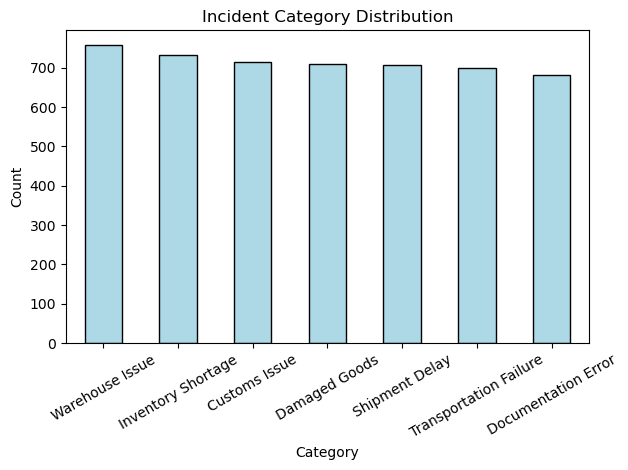

In [3]:
df['incident_category'].value_counts().plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Incident Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Observation:** All categories are well balanced with approximately 700 tickets each. This is ideal for classification as the model won't be biased towards any one category.

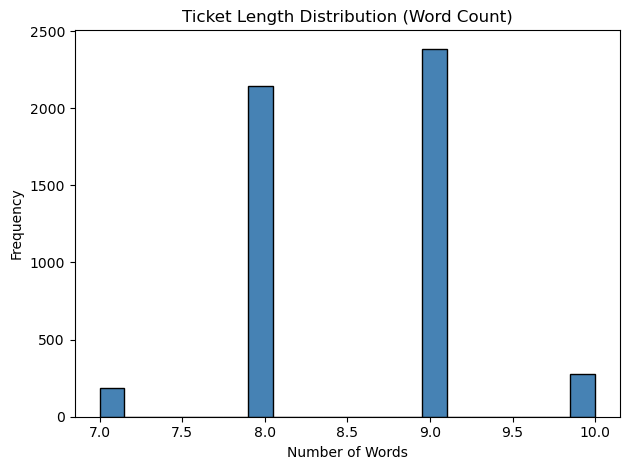

In [5]:
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

df['text_length'].plot(kind='hist', bins=20, color='steelblue', edgecolor='black')
plt.title('Ticket Length Distribution (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Observation:** Unlike a real-world dataset which would show a wide spread of ticket lengths, this histogram shows almost all tickets are either 8 or 9 words long after preprocessing, reflecting the templated structure of the data.

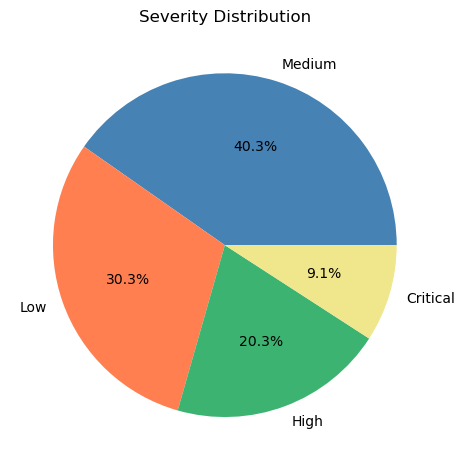

In [24]:
df['severity'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['steelblue', 'coral', 'mediumseagreen', 'khaki'])
plt.title('Severity Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Observation:** Most tickets are Medium (40%) or Low (30%) severity. Only 9% are Critical, which makes sense since if most incidents were critical, the supply chain would be in serious trouble. 

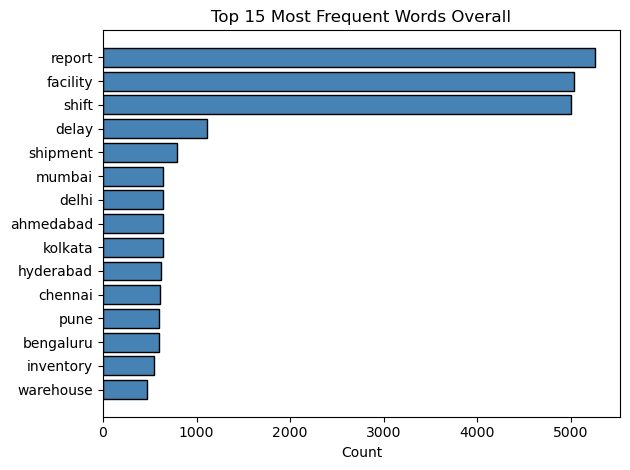

In [26]:
all_words = ' '.join(df['clean_text']).split()
word_counts = Counter(all_words).most_common(15)

words, counts = zip(*word_counts)
plt.barh(words, counts, color='steelblue', edgecolor='black')
plt.title('Top 15 Most Frequent Words Overall')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Observation:** 'Report', 'facility', and 'shift' completely dominate the chart. These are template words that appear in every single ticket regardless of category. The actual meaningful words like 'delay', 'shipment', 'inventory' are far smaller. This tells us the classifier will need to work hard to find signal through a lot of noise.

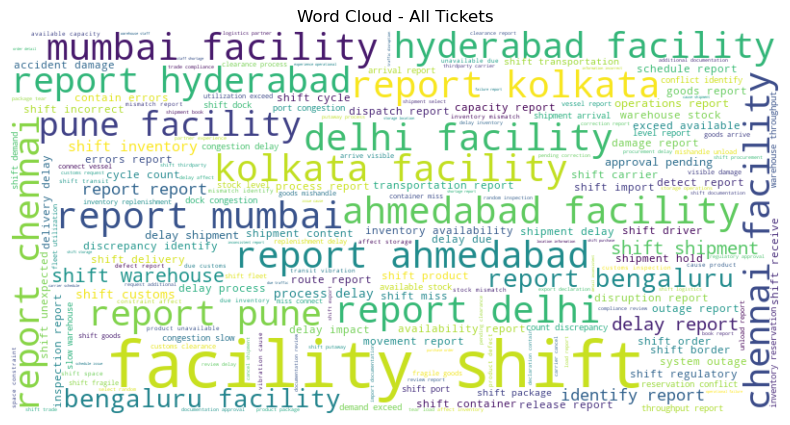

In [51]:
all_text = ' '.join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - All Tickets')
plt.show()

**Observation:** 'Facility' and 'shift' are enormous because they're in every ticket as descriptors. The city names (Mumbai, Delhi, Chennai etc.) are large too since every ticket specifies a location, but location shouldn't determine incident category. The category-specific words are visible but small.

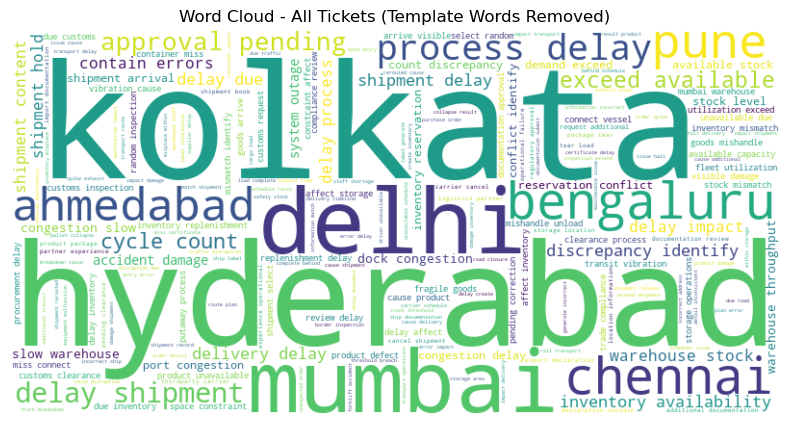

In [53]:
extra_words = ['report', 'facility', 'shift']

filtered_text = ' '.join([
    word for word in ' '.join(df['clean_text']).split()
    if word not in extra_words
])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - All Tickets (Template Words Removed)')
plt.show()

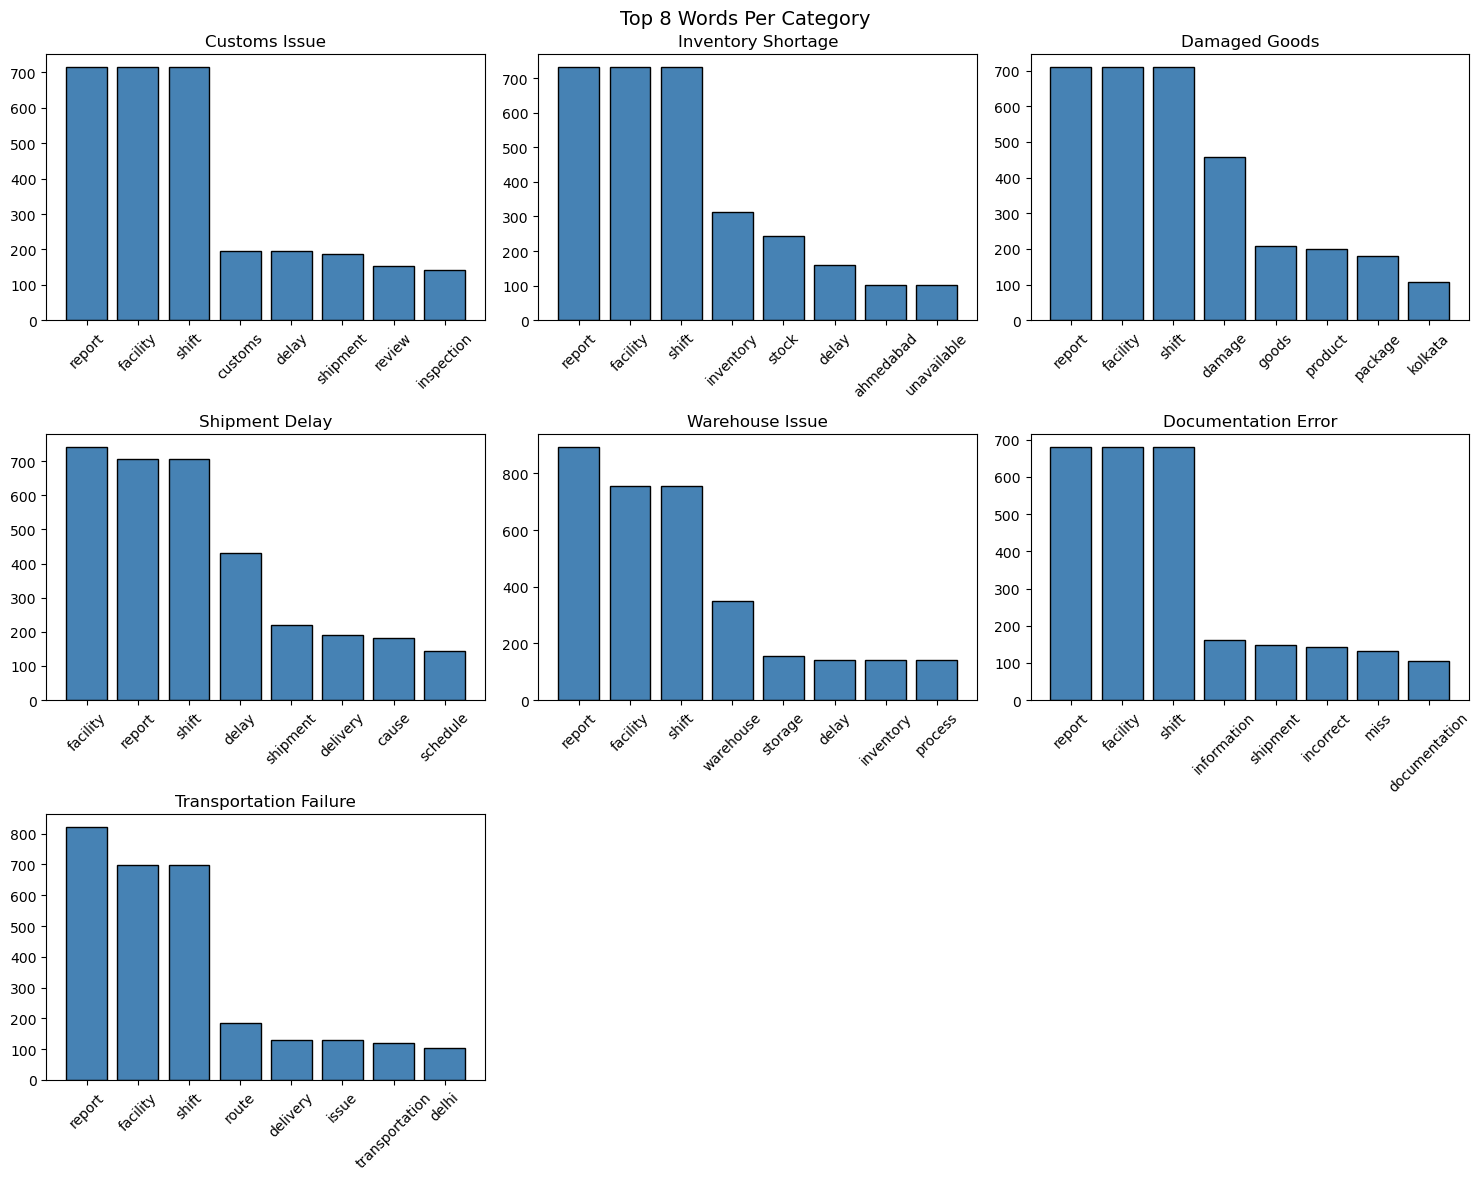

In [45]:
categories = df['incident_category'].unique()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, category in enumerate(categories):
    cat_words = ' '.join(df[df['incident_category'] == category]['clean_text']).split()
    word_counts = Counter(cat_words).most_common(8)
    words, counts = zip(*word_counts)
    
    axes[i].bar(words, counts, color='steelblue', edgecolor='black')
    axes[i].set_title(category)
    axes[i].tick_params(axis='x', rotation=45)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 8 Words Per Category', fontsize=14)
plt.tight_layout()
plt.show()

**Observation:** Every category has the same three dominant words: 'report', 'facility', 'shift'. The category-specific keywords only appear from position 4 onwards - 'customs' for Customs Issue, 'damage' for Damaged Goods, 'delay' for Shipment Delay. 

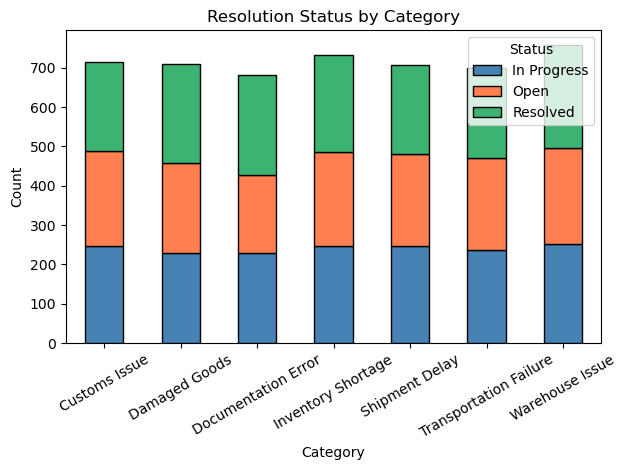

In [28]:
resolution_counts = df.groupby(['incident_category', 'resolution_status']).size().unstack()

resolution_counts.plot(kind='bar', stacked=True, color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='black')
plt.title('Resolution Status by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

**Observation:** All categories have almost identical resolution splits, roughly one third each.. No category stands out as particularly backlogged or well-resolved. In reality you'd expect Customs Issues or Transportation Failures to have more open tickets due to their complexity

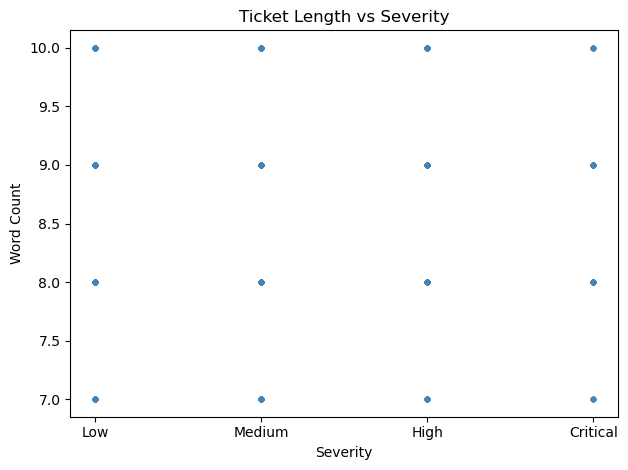

In [30]:
severity_order = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df['severity_num'] = df['severity'].map(severity_order)

plt.scatter(df['severity_num'], df['text_length'], alpha=0.2, color='steelblue', s=10)
plt.xticks([1, 2, 3, 4], ['Low', 'Medium', 'High', 'Critical'])
plt.title('Ticket Length vs Severity')
plt.xlabel('Severity')
plt.ylabel('Word Count')
plt.tight_layout()
plt.show()

**Observation:** This scatter plot visually exposes the artificial nature of the dataset. Every severity level contains tickets of exactly the same lengths 7-10 words which forms a perfect grid. In real incident data, Critical tickets would typically be far longer and more detailed than Low severity ones. 